

## ESTE SCRIPT SIRVE PARA RELACIONAR EL COEFICIENTE FLECTOR K CON LOS GRADOS DEL SERVO MOTOR

Para ello solo es necesario introducir los parametros de la viga(longitud de cada tramo) y la defromación y_max (medida en la cola del prototpo) del prototipo para cada grado del servomotor



Longitud de cuerda total de la viga: 20.000 cm
Rango de x: [0.000, 20.000] cm
Rango de y (camber): [-4.851, 0.000] cm


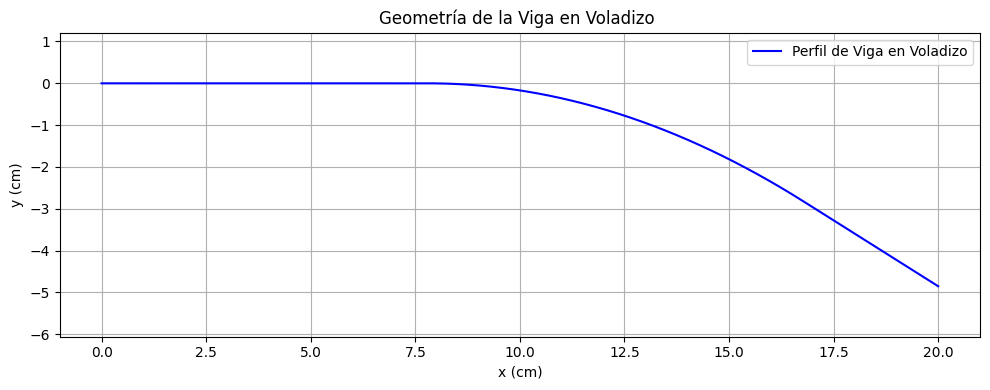

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_cantilever_beam_data(L1, L2, L3, factor_flexion, num_puntos_por_seccion=100):

    # Sección 1: Tramo rígido
    # Usamos endpoint=True para cerrar bien el tramo
    x1 = np.linspace(0, L1, num_puntos_por_seccion, endpoint=True)
    y1 = np.zeros_like(x1)
    dzdx1 = np.zeros_like(x1)

    # Sección 2: Tramo curvo
    # Al poner endpoint=True, el último punto será exactamente el final de L2
    x2_prime = np.linspace(0, L2, num_puntos_por_seccion, endpoint=True)
    x2 = x2_prime + L1
    y_flex_relative = -factor_flexion * x2_prime**2 / 2
    dzdx_flex_relative = -factor_flexion * x2_prime
    y2 = y_flex_relative
    dzdx2 = dzdx_flex_relative

    # Guardamos los valores EXACTOS al final del tramo 2
    y_at_end_L2 = y_flex_relative[-1]
    dzdx_at_end_L2 = dzdx_flex_relative[-1]

    # Sección 3: Tramo recto
    # Para evitar duplicar el punto de unión (L1 + L2), definimos los puntos
    # desde el primer paso posterior hasta el final de L3.
    x3_prime_completo = np.linspace(0, L3, num_puntos_por_seccion, endpoint=True)
    dx3 = x3_prime_completo[1] - x3_prime_completo[0] # Tamaño del paso numérico

    # Empezamos el tramo 3 un paso adelante para una transición limpia
    x3_prime = np.linspace(dx3, L3, num_puntos_por_seccion - 1, endpoint=True)
    x3 = x3_prime + L1 + L2

    # La altura se calcula con la ecuación de la recta partiendo del final real de L2
    y3 = y_at_end_L2 + dzdx_at_end_L2 * x3_prime
    dzdx3 = np.full_like(x3, dzdx_at_end_L2)

    # Combina todos los puntos y asegura el ordenamiento por x
    x_combined = np.concatenate((x1, x2, x3))
    y_combined = np.concatenate((y1, y2, y3))
    dzdx_combined = np.concatenate((dzdx1, dzdx2, dzdx3))

    sort_indices = np.argsort(x_combined)
    x_beam = x_combined[sort_indices]
    y_beam = y_combined[sort_indices]
    dzdx_beam = dzdx_combined[sort_indices]

    c_beam = L1 + L2 + L3
    return x_beam, y_beam, dzdx_beam, c_beam

# --- Definición de parámetros de la viga ---
L1_beam = 7.8  # cm
L2_beam = 9    # cm
L3_beam = 3.2  # cm
factor_flexion_viga = 0.07 # flex_factor
num_puntos = 200 # num_points

# Generar los datos corregidos
x_beam, y_beam, dzdx_beam, c_beam = generate_cantilever_beam_data(
    L1_beam, L2_beam, L3_beam, factor_flexion_viga, num_puntos_por_seccion=num_puntos//3
)

print(f"Longitud de cuerda total de la viga: {c_beam:.3f} cm")
print(f"Rango de x: [{x_beam.min():.3f}, {x_beam.max():.3f}] cm")
print(f"Rango de y (camber): [{y_beam.min():.3f}, {y_beam.max():.3f}] cm")

# Gráfico del perfil de la viga
plt.figure(figsize=(10, 4))
plt.plot(x_beam, y_beam, 'b-', label='Perfil de Viga en Voladizo')
plt.title('Geometría de la Viga en Voladizo ')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

### Relación entre el factor de flexión (k) y la deflexión máxima (y_max)

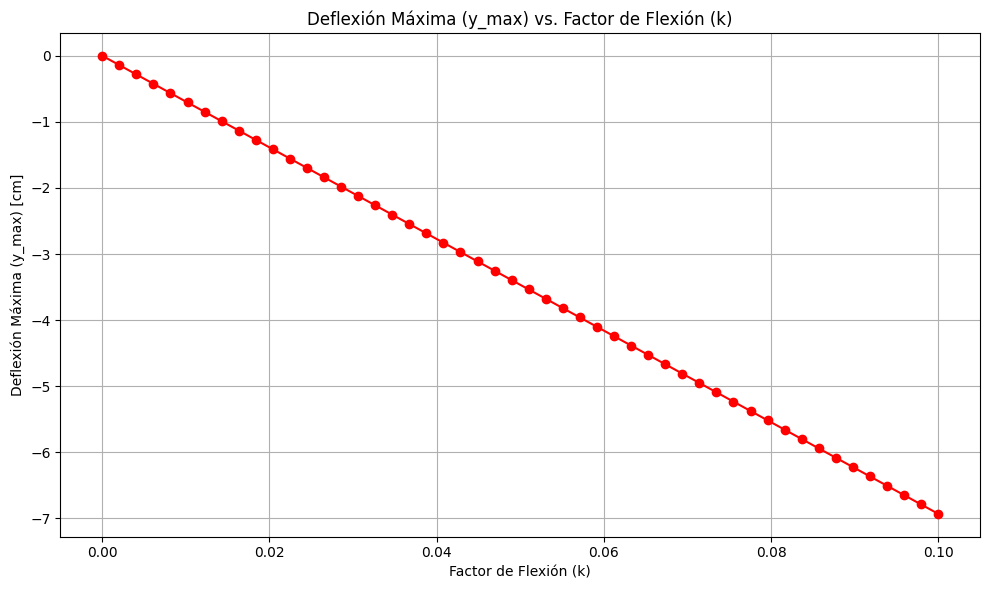

In [ ]:
k_values = np.linspace(0, 0.1, 50) # Define un rango de factores de flexión
y_max_values = []

for k in k_values:
    _, y_beam_current, _, _ = generate_cantilever_beam_data(
        L1_beam, L2_beam, L3_beam, k, num_puntos_por_seccion=num_puntos//3
    )
    y_max_values.append(y_beam_current.min())

plt.figure(figsize=(10, 6))
plt.plot(k_values, y_max_values, 'o-', color='red')
plt.title('Deflexión Máxima (y_max) vs. Factor de Flexión (k)')
plt.xlabel('Factor de Flexión (k)')
plt.ylabel('Deflexión Máxima (y_max) [cm]')
plt.grid(True)
plt.tight_layout()
plt.show()

### Relación entre el Ángulo del Servo y la Deflexión Máxima (y_max)

Este gráfico muestra los valores de `y_max` que has proporcionado para cada ángulo de servo.

In [ ]:
# Define los ángulos para los cuales tienes datos experimentales de y_max
angles = np.arange(0,19) # Ángulos de 98 a 110 grados

# IMPORTANTE: Reemplaza los valores de ejemplo a continuación con tus valores reales de y_max medidos para cada ángulo.
y_max_for_angles = [
    0,     -0.21, -0.5,  -0.75, -1.05,
    -1.35, -1.7,  -1.95, -2.2,  -2.5,
    -2.75, -3.05, -3.3,  -3.65, -3.85,
    -4.25, -4.5,  -4.6,  -4.8
]


if len(angles) != len(y_max_for_angles):
    raise ValueError(f"Se esperaban {len(angles)} valores de y_max, pero se obtuvieron {len(y_max_for_angles)}. Por favor, proporciona un valor de y_max para cada ángulo de 98 a 110.")

print("Datos de entrada recibidos. Procediendo a calcular los valores de k y graficar la relación.")

Datos de entrada recibidos. Procediendo a calcular los valores de k y graficar la relación.


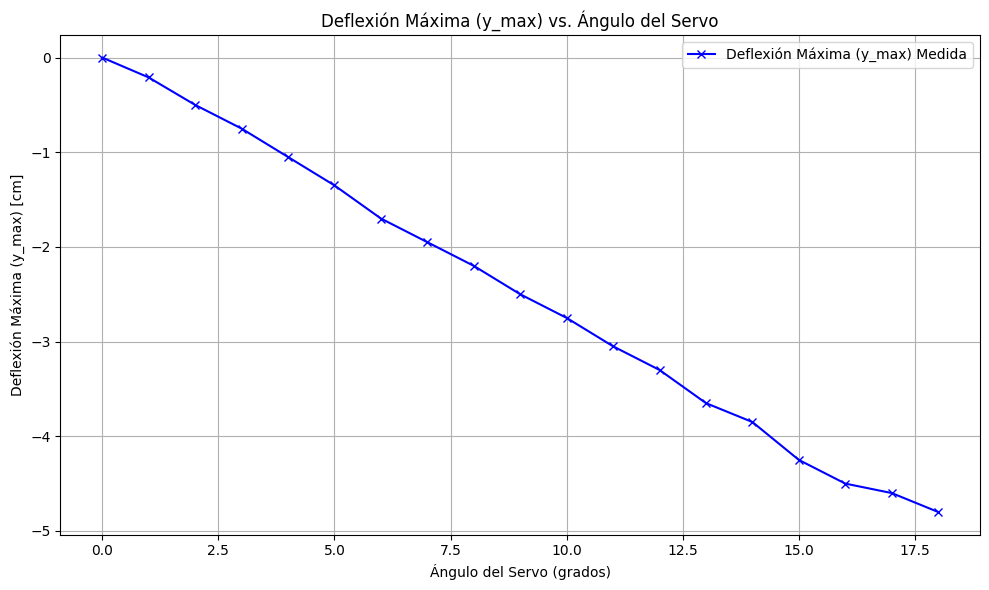

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(angles, y_max_for_angles, 'x-', color='blue', label='Deflexión Máxima (y_max) Medida')
plt.title('Deflexión Máxima (y_max) vs. Ángulo del Servo')
plt.xlabel('Ángulo del Servo (grados)')
plt.ylabel('Deflexión Máxima (y_max) [cm]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Ecuación de Relación entre el Factor de Flexión (k) y el Ángulo del Servo

Podemos encontrar una aproximación de la relación `k` vs `ángulo` mediante una regresión lineal.

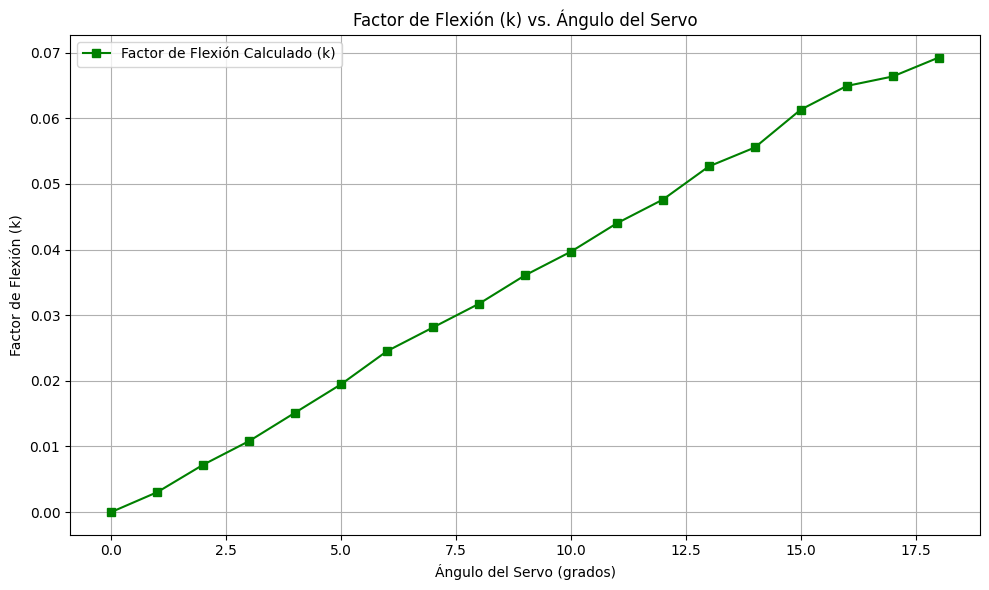

Valores de k calculados para cada ángulo:
Ángulo: 0° -> Factor de Flexión (k): 0.0000
Ángulo: 1° -> Factor de Flexión (k): 0.0030
Ángulo: 2° -> Factor de Flexión (k): 0.0072
Ángulo: 3° -> Factor de Flexión (k): 0.0108
Ángulo: 4° -> Factor de Flexión (k): 0.0152
Ángulo: 5° -> Factor de Flexión (k): 0.0195
Ángulo: 6° -> Factor de Flexión (k): 0.0245
Ángulo: 7° -> Factor de Flexión (k): 0.0281
Ángulo: 8° -> Factor de Flexión (k): 0.0317
Ángulo: 9° -> Factor de Flexión (k): 0.0361
Ángulo: 10° -> Factor de Flexión (k): 0.0397
Ángulo: 11° -> Factor de Flexión (k): 0.0440
Ángulo: 12° -> Factor de Flexión (k): 0.0476
Ángulo: 13° -> Factor de Flexión (k): 0.0527
Ángulo: 14° -> Factor de Flexión (k): 0.0556
Ángulo: 15° -> Factor de Flexión (k): 0.0613
Ángulo: 16° -> Factor de Flexión (k): 0.0649
Ángulo: 17° -> Factor de Flexión (k): 0.0664
Ángulo: 18° -> Factor de Flexión (k): 0.0693


In [ ]:
# Usa los valores de k_values y y_max_values generados previamente para la interpolación
# Asegúrate de que los valores de y_max sean positivos para la interpolación si k_values están ordenados por abs(y_max)
# Nota: los valores de y_max suelen ser negativos, por lo que usamos sus valores absolutos para la interpolación.
abs_y_max_values_ref = np.abs(y_max_values)

# Interpola para encontrar k para cada y_max_for_angle
# np.interp espera que las coordenadas x (abs_y_max_values_ref) sean crecientes.
k_for_angles = np.interp(np.abs(y_max_for_angles), abs_y_max_values_ref, k_values)

# Grafica la relación entre los ángulos y k_for_angles
plt.figure(figsize=(10, 6))
plt.plot(angles, k_for_angles, 's-', color='green', label='Factor de Flexión Calculado (k)')
plt.title('Factor de Flexión (k) vs. Ángulo del Servo')
plt.xlabel('Ángulo del Servo (grados)')
plt.ylabel('Factor de Flexión (k)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Valores de k calculados para cada ángulo:")
for angle, k_val in zip(angles, k_for_angles):
    print(f"Ángulo: {angle}° -> Factor de Flexión (k): {k_val:.4f}")

### Relación entre el Ángulo del Servo y el Factor de Flexión (k)

Ahora, estableceremos la relación entre el ángulo del servo y el factor de flexión `k` utilizando tus valores experimentales de `y_max`.

Resultados de la Regresión Lineal:
  Pendiente (m): 0.004002
  Intercepción (b): -0.000350
  Coeficiente de Correlación (R): 0.9991
  Error Estándar: 0.000040

La ecuación de relación aproximada es: k = 0.004002 * Ángulo + -0.000350


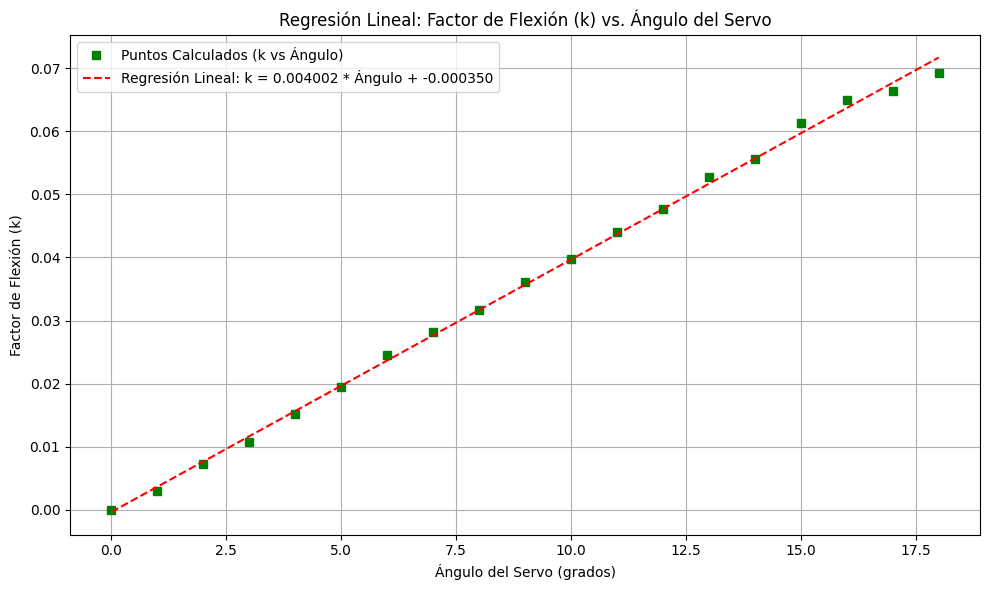

In [ ]:
from scipy.stats import linregress

# Realizar la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(angles, k_for_angles)

print(f"Resultados de la Regresión Lineal:")
print(f"  Pendiente (m): {slope:.6f}")
print(f"  Intercepción (b): {intercept:.6f}")
print(f"  Coeficiente de Correlación (R): {r_value:.4f}")
print(f"  Error Estándar: {std_err:.6f}")

# Ecuación de la relación
equation = f"k = {slope:.6f} * Ángulo + {intercept:.6f}"
print(f"\nLa ecuación de relación aproximada es: {equation}")

# Graficar la línea de regresión junto con los puntos calculados
plt.figure(figsize=(10, 6))
plt.plot(angles, k_for_angles, 's', color='green', label='Puntos Calculados (k vs Ángulo)')
plt.plot(angles, slope * angles + intercept, 'r--', label=f'Regresión Lineal: {equation}')
plt.title('Regresión Lineal: Factor de Flexión (k) vs. Ángulo del Servo')
plt.xlabel('Ángulo del Servo (grados)')
plt.ylabel('Factor de Flexión (k)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()